In [1]:
import numpy as np

In [2]:
rng = np.random.default_rng(42)

In [3]:
runs = 1000
N = 1000
ks = np.arange(1, N + 1, 1, dtype=int)
ps = np.linspace(0.0, 1.0, 11, endpoint=True)

In [4]:
from tqdm import tqdm

In [5]:
ts = []
for k in tqdm(ks):
    for p in ps:
        for r in range(runs):
            # Fase 1: seleciona de uma hipergeométrica com nbad = (1 - p)*(N - k)
            ngood = int(np.floor(p * k))
            nbad = int(np.floor((1.0 - p) * (N - k)))
            d = rng.hypergeometric(ngood=ngood, nbad=nbad, nsample=ngood)

            # Fase 2: seleciona de uma hipergeométrica com ngood = p * (k - d)
            ngood = int(np.floor((1.0 - p) * k))
            nbad = int(np.floor(p * (N - k)))
            m = rng.hypergeometric(ngood=ngood, nbad=nbad, nsample=ngood)

            t = d + m
            ts.append((k, p, r, t))

100%|██████████| 1000/1000 [01:02<00:00, 16.06it/s]


In [6]:
import pandas as pd

cols = ["k", "p", "r", "t"]
df_ts = pd.DataFrame(ts, columns=cols)

In [7]:
df_ts

,k,p,r,t
0,1,0.0,0,1
1,1,0.0,1,1
2,1,0.0,2,1
3,1,0.0,3,1
4,1,0.0,4,1
...,...,...,...,...
10999995,1000,1.0,995,1000
10999996,1000,1.0,996,1000
10999997,1000,1.0,997,1000
10999998,1000,1.0,998,1000


In [8]:
nngs = df_ts["t"] / (2.0 * df_ts["k"] - df_ts["t"])

In [9]:
df_nngs = df_ts.drop(columns=["t"])
df_nngs["nngs"] = nngs

In [10]:
df_nngs_mean = df_nngs.groupby(["k", "p"])["nngs"].mean().unstack()

In [11]:
df_nngs_mean.iloc[:10, :]

p,0.0,0.1,0.2,0.3,0.4,0.5,0.6,0.7,0.8,0.9,1.0
k,,,,,,,,,,,
1,1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
2,1.0,0.003333,0.002667,0.001000,0.000333,0.001333,0.001667,0.000333,0.002333,0.003667,1.0
3,1.0,0.011200,0.004000,0.004000,0.001400,0.000400,0.000800,0.002200,0.003800,0.007600,1.0
4,1.0,0.013143,0.007429,0.002571,0.001000,0.002286,0.001000,0.002429,0.006619,0.014048,1.0
5,1.0,0.017056,0.008917,0.003556,0.002917,0.001889,0.002111,0.003917,0.007750,0.017306,1.0
6,1.0,0.024461,0.007382,0.004545,0.002836,0.003818,0.002455,0.004636,0.006036,0.020224,1.0
7,1.0,0.029251,0.010141,0.005154,0.004308,0.002615,0.003321,0.005385,0.009526,0.027247,1.0
8,1.0,0.031073,0.012905,0.006048,0.003000,0.004419,0.003343,0.006581,0.012290,0.033937,1.0
9,1.0,0.036337,0.014735,0.007213,0.004360,0.002765,0.003949,0.006809,0.014157,0.035409,1.0


In [12]:
nngs_lower_bound = ks / (2*N - ks)

In [13]:
df_nngs_mean_normalized = (df_nngs_mean - nngs_lower_bound[:, np.newaxis]) / (1.0 - nngs_lower_bound[:, np.newaxis])

In [14]:
import matplotlib.pyplot as plt

In [15]:
k_max_plot = 30

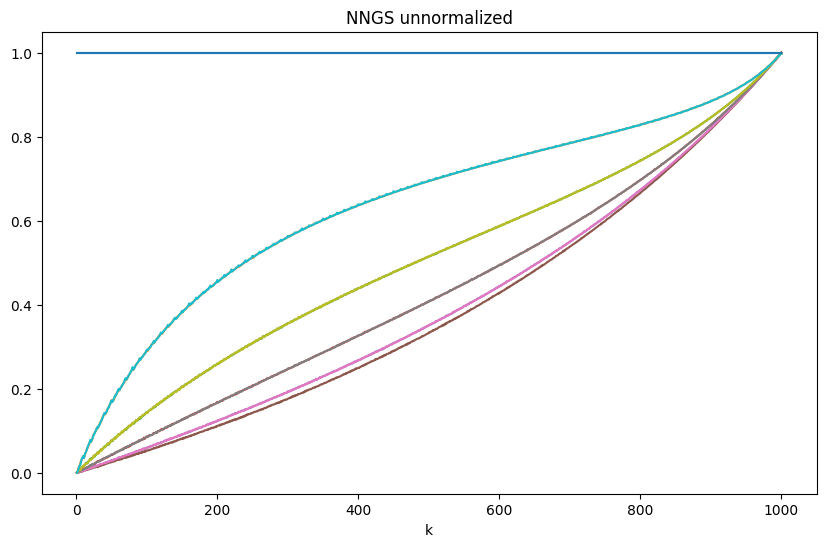

In [16]:
plt.figure(figsize=(10, 6))
df_nngs_mean.plot(ax=plt.gca(), legend=False, title="NNGS unnormalized")
plt.show()

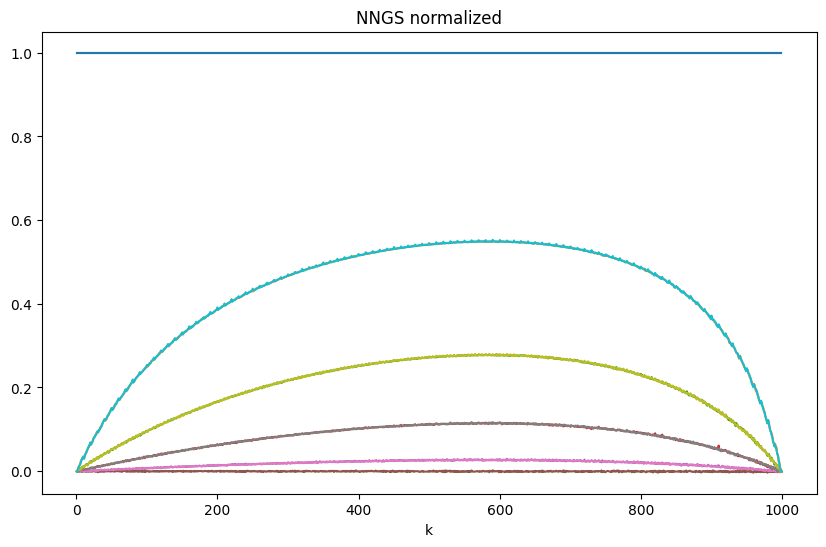

In [17]:
plt.figure(figsize=(10, 6))
df_nngs_mean_normalized.plot(ax=plt.gca(), legend=False, title="NNGS normalized")
plt.show()